In [ ]:
import numpy as np  # numerika
import matplotlib.pyplot as plt  # grafy
from matplotlib.gridspec import GridSpec  # rozvržení

from UQpy.distributions import Uniform, JointIndependent  # rozdělení
from UQpy.sampling import MonteCarloSampling, LatinHypercubeSampling  # vzorkování

try:
    from UQpy.sampling import ThetaCriterionPCE  # Theta metoda
except Exception:
    from UQpy.sampling.ThetaCriterionPCE import ThetaCriterionPCE  # náhradní import

try:
    from UQpy.sampling.stratified_sampling.latin_hypercube_criteria import MaxiMin  # MaxiMin
except Exception:
    from UQpy.sampling.stratified_sampling.latin_hypercube_criteria.maxi_min import MaxiMin  # náhradní import

from UQpy.surrogates import (
    PolynomialChaosExpansion,
    TotalDegreeBasis,
    LeastSquareRegression,
)

In [ ]:



def gaussian_hill(X, mu1, mu2, sigma1, sigma2):  # cílová funkce
    x1 = X[:, 0]  # souřadnice x1
    x2 = X[:, 1]  # souřadnice x2

    exponent = (
        ((x1 - mu1) ** 2) / (2 * sigma1 ** 2)
        + ((x2 - mu2) ** 2) / (2 * sigma2 ** 2)
    )  # exponent

    return np.exp(-exponent)  # hodnota funkce


def get_samples(sampler):  # získání vzorků
    if hasattr(sampler, "samples"):
        return sampler.samples

    if hasattr(sampler, "_samples"):
        return sampler._samples

    raise RuntimeError("Samples were not found in the sampler object.")  # chybějící vzorky


def create_joint_distribution():  # společné rozdělení
    dist1 = Uniform(loc=0.0, scale=1.0)  # rozdělení x1
    dist2 = Uniform(loc=0.0, scale=1.0)  # rozdělení x2
    joint = JointIndependent(marginals=[dist1, dist2])  # spojení rozdělení

    return dist1, dist2, joint  # výstup rozdělení


def random_points(n, seed, dist1, dist2):  # náhodné body
    np.random.seed(seed)  # lokální seed

    sampler = MonteCarloSampling(
        distributions=[dist1, dist2],
        nsamples=n
    )

    return get_samples(sampler)  # vrácení bodů


def lhs_maximin_points(n, seed, dist1, dist2):  # LHS body
    np.random.seed(seed)  # lokální seed

    try:
        criterion = MaxiMin()  # MaxiMin kritérium
        sampler = LatinHypercubeSampling(
            distributions=[dist1, dist2],
            criterion=criterion,
            nsamples=n
        )
    except Exception:
        sampler = LatinHypercubeSampling(
            distributions=[dist1, dist2],
            nsamples=n
        )

    return get_samples(sampler)  # vrácení bodů


def split_points(X, n_initial):  # rozdělení bodů
    X_initial = X[:n_initial]  # počáteční body
    X_selected = X[n_initial:]  # vybrané body

    return X_initial, X_selected  # vrácení částí


def inset_points_for_plot(X, eps=0.015):  # posun bodů
    Xp = X.copy()  # kopie bodů
    Xp[:, 0] = np.clip(Xp[:, 0], eps, 1.0 - eps)  # omezení x1
    Xp[:, 1] = np.clip(Xp[:, 1], eps, 1.0 - eps)  # omezení x2

    return Xp  # upravené body


def create_theta_points(settings, dist1, dist2, joint):  # Theta výběr
    n_initial = settings["n_initial"]  # počáteční počet
    n_adaptive = settings["n_adaptive"]  # vybraný počet
    n_candidates = settings["n_candidates"]  # počet kandidátů

    mu1 = settings["mu1"]  # poloha x1
    mu2 = settings["mu2"]  # poloha x2
    sigma1 = settings["sigma1"]  # šířka x1
    sigma2 = settings["sigma2"]  # šířka x2

    X_initial = lhs_maximin_points(n_initial, 31, dist1, dist2)  # počáteční body
    Y_theta = gaussian_hill(X_initial, mu1, mu2, sigma1, sigma2)  # počáteční odezvy

    X_theta = X_initial.copy()  # trénovací body
    X_candidates = lhs_maximin_points(n_candidates, 41, dist1, dist2)  # kandidátní body

    basis = TotalDegreeBasis(joint, 3)  # PCE báze
    regression = LeastSquareRegression()  # regrese

    X_selected = []  # vybrané body

    for _ in range(n_adaptive):
        pce = PolynomialChaosExpansion(
            polynomial_basis=basis,
            regression_method=regression
        )

        pce.fit(X_theta, Y_theta)  # fit PCE

        theta = ThetaCriterionPCE([pce])  # Theta kritérium

        pos = theta.run(
            existing_samples=X_theta,
            candidate_samples=X_candidates,
            nsamples=1
        )

        pos = int(np.ravel(pos)[0])  # index bodu

        new_x = X_candidates[pos:pos + 1, :]  # nový bod
        new_y = gaussian_hill(new_x, mu1, mu2, sigma1, sigma2)  # nová odezva

        X_selected.append(new_x[0])  # uložení bodu

        X_theta = np.vstack([X_theta, new_x])  # rozšíření X
        Y_theta = np.r_[Y_theta, new_y]  # rozšíření Y

        X_candidates = np.delete(X_candidates, pos, axis=0)  # smazání kandidáta

    return X_initial, np.array(X_selected)  # Theta body


def create_surface(settings):  # plocha funkce
    grid = settings["grid"]  # hustota mřížky

    x1 = np.linspace(0.0, 1.0, grid)  # osa x1
    x2 = np.linspace(0.0, 1.0, grid)  # osa x2

    X1, X2 = np.meshgrid(x1, x2)  # plošná mřížka
    X_grid = np.column_stack([X1.ravel(), X2.ravel()])  # body mřížky

    Z = gaussian_hill(
        X_grid,
        settings["mu1"],
        settings["mu2"],
        settings["sigma1"],
        settings["sigma2"]
    ).reshape(grid, grid)  # hodnoty funkce

    return X1, X2, Z  # výstup plochy


def set_plot_style():  # styl grafů
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "mathtext.fontset": "dejavusans",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#111827",
        "axes.linewidth": 1.3,
        "axes.labelsize": 24,
        "axes.titlesize": 22,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 18,
    })


def setup_axis(ax, title, show_grid, X1, X2, Z, line_levels):  # nastavení os
    ax.contourf(
        X1, X2, Z,
        levels=[0.20, 0.40, 0.60, 0.80, 1.00],
        colors=["#f8fafc", "#eef2f7", "#dbe4ef", "#bcc9d8"],
        alpha=1.0
    )

    ax.contour(
        X1, X2, Z,
        levels=line_levels,
        colors="#94a3b8",
        linewidths=1.25,
        alpha=0.95
    )

    ax.set_title(title, pad=14, fontweight="bold", fontsize=22)  # název grafu
    ax.set_xlabel(r"$x_1$", labelpad=8)  # popis x1
    ax.set_ylabel(r"$x_2$", labelpad=8)  # popis x2

    ax.set_xlim(0.0, 1.0)  # rozsah x1
    ax.set_ylim(0.0, 1.0)  # rozsah x2
    ax.set_aspect("equal", adjustable="box")  # stejný poměr

    ax.set_xticks(np.linspace(0.0, 1.0, 6))  # značky x1
    ax.set_yticks(np.linspace(0.0, 1.0, 6))  # značky x2

    if show_grid:
        ax.grid(True, color="#d1d5db", linewidth=1.0, alpha=0.8)  # mřížka
    else:
        ax.grid(False)  # bez mřížky

    ax.tick_params(direction="out", length=6, width=1.1, pad=6)  # značky os

    for spine in ax.spines.values():
        spine.set_color("#111827")  # barva rámečku
        spine.set_linewidth(1.2)  # tloušťka rámečku
        spine.set_zorder(20)  # pořadí rámečku


def draw_points(ax, X_initial, X_selected):  # vykreslení bodů
    X_initial_plot = inset_points_for_plot(X_initial, eps=0.012)  # počáteční body
    X_selected_plot = inset_points_for_plot(X_selected, eps=0.012)  # vybrané body

    h_initial = ax.scatter(
        X_initial_plot[:, 0],
        X_initial_plot[:, 1],
        s=105,
        c="#2563eb",
        edgecolors="white",
        linewidths=1.0,
        zorder=6,
        clip_on=True,
        label="Initial points"
    )

    h_selected = ax.scatter(
        X_selected_plot[:, 0],
        X_selected_plot[:, 1],
        s=180,
        facecolors="white",
        edgecolors="#374151",
        linewidths=2.0,
        zorder=5,
        clip_on=True,
        label="Selected points"
    )

    return h_initial, h_selected  # objekty legendy


def add_titles(fig):  # nadpisy obrázku
    fig.suptitle(
        "Comparison of Point Selection Strategies on a Gaussian Function",
        fontsize=32,
        fontweight="bold",
        y=0.990
    )

    formula = (
        r"$f(x_1,x_2)=\exp\left[-\left("
        r"\frac{(x_1-0.70)^2}{2\cdot0.13^2}"
        r"+"
        r"\frac{(x_2-0.35)^2}{2\cdot0.10^2}"
        r"\right)\right]$"
    )

    fig.text(
        0.5, 0.875,
        formula,
        ha="center",
        va="center",
        fontsize=25
    )


def save_figure():  # uložení obrázků
    plt.savefig(
        "sampling_strategies_presentation_spacing_adjusted.png",
        dpi=450,
        bbox_inches="tight",
        facecolor="white"
    )  # uložení PNG

    plt.savefig(
        "sampling_strategies_presentation_spacing_adjusted.pdf",
        bbox_inches="tight",
        facecolor="white"
    )  # uložení PDF

    plt.savefig(
        "sampling_strategies_presentation_spacing_adjusted.svg",
        bbox_inches="tight",
        facecolor="white"

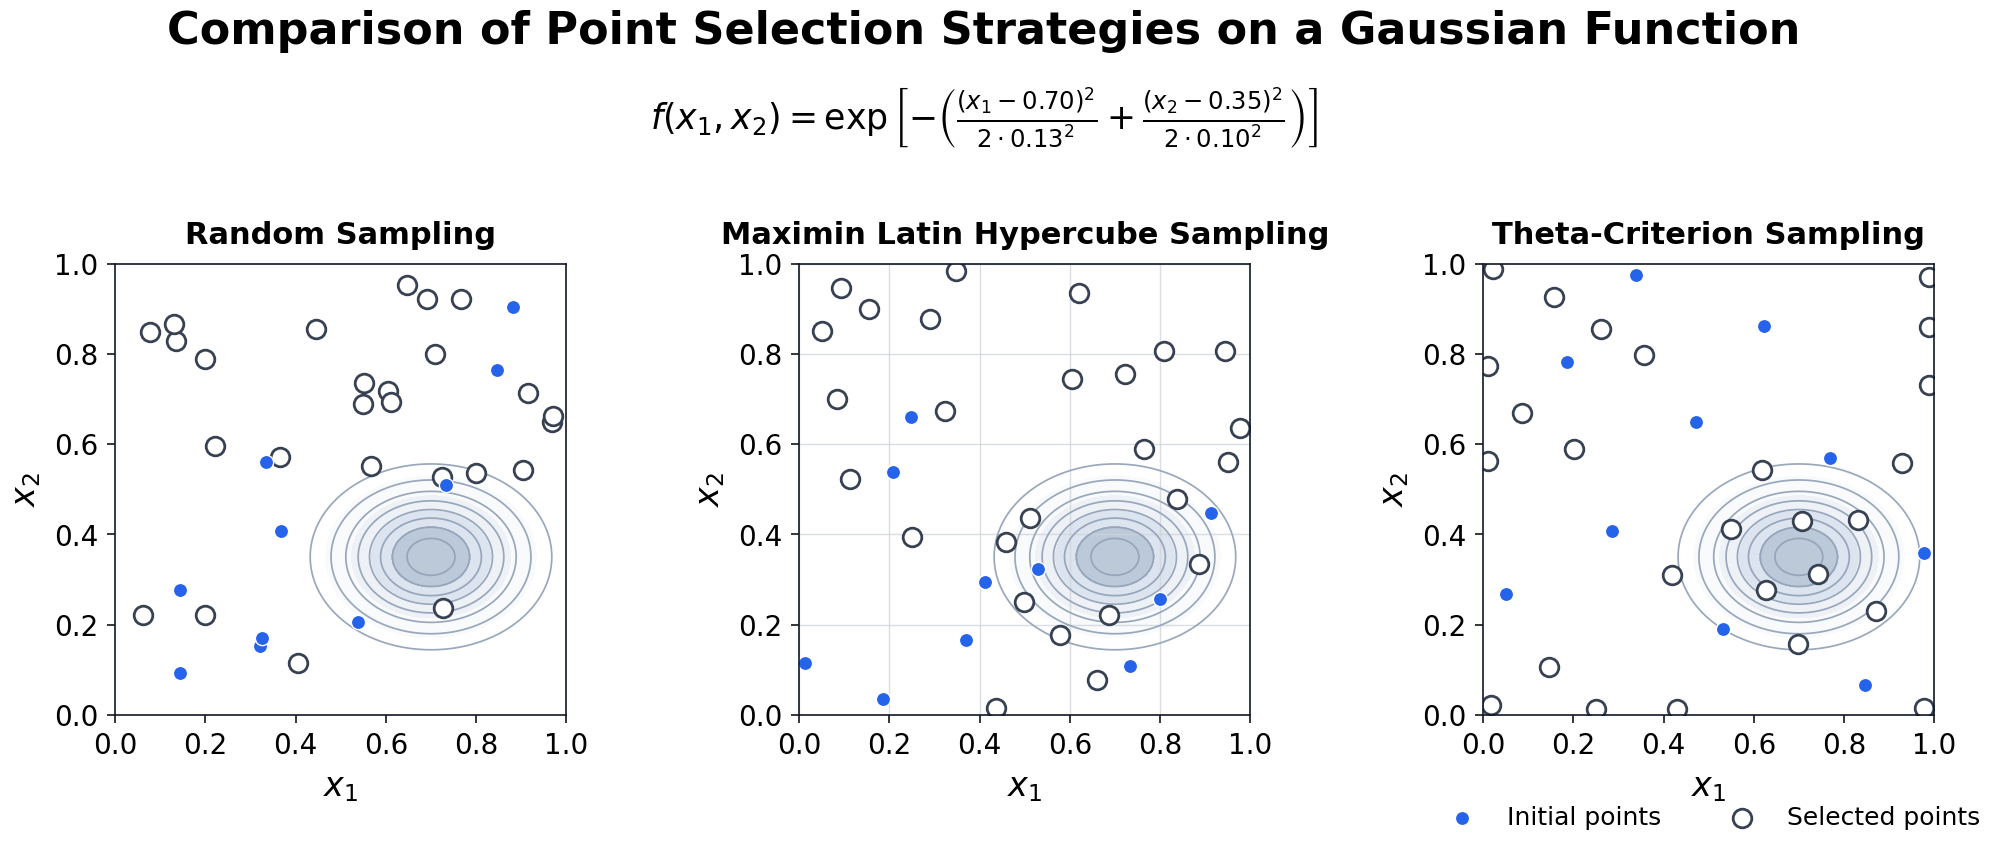

In [59]:

def main():  # hlavní funkce
    np.random.seed(4)  # globální seed

    settings = {
        "n_total": 36,
        "n_initial": 10,
        "n_adaptive": 26,
        "n_candidates": 3500,
        "mu1": 0.70,
        "mu2": 0.35,
        "sigma1": 0.13,
        "sigma2": 0.10,
        "grid": 350,
    }  # vstupní hodnoty

    dist1, dist2, joint = create_joint_distribution()  # rozdělení

    X_random = random_points(settings["n_total"], 11, dist1, dist2)  # Random body
    X_lhs = lhs_maximin_points(settings["n_total"], 21, dist1, dist2)  # LHS body

    X_random_initial, X_random_selected = split_points(X_random, settings["n_initial"])  # Random části
    X_lhs_initial, X_lhs_selected = split_points(X_lhs, settings["n_initial"])  # LHS části

    X_theta_initial, X_theta_selected = create_theta_points(settings, dist1, dist2, joint)  # Theta části

    X1, X2, Z = create_surface(settings)  # plocha funkce
    line_levels = np.linspace(0.12, 0.92, 8)  # úrovně vrstevnic

    set_plot_style()  # nastavení stylu

    fig = plt.figure(figsize=(20.5, 9.4), facecolor="white")  # hlavní obrázek

    gs = GridSpec(
        1, 3,
        figure=fig,
        left=0.045,
        right=0.995,
        bottom=0.24,
        top=0.72,
        wspace=0.18
    )  # rozvržení grafů

    ax1 = fig.add_subplot(gs[0, 0])  # Random graf
    ax2 = fig.add_subplot(gs[0, 1])  # LHS graf
    ax3 = fig.add_subplot(gs[0, 2])  # Theta graf

    add_titles(fig)  # vložení nadpisů

    setup_axis(ax1, "Random Sampling", False, X1, X2, Z, line_levels)  # osa Random
    draw_points(ax1, X_random_initial, X_random_selected)  # body Random

    setup_axis(ax2, "Maximin Latin Hypercube Sampling", True, X1, X2, Z, line_levels)  # osa LHS
    draw_points(ax2, X_lhs_initial, X_lhs_selected)  # body LHS

    setup_axis(ax3, "Theta-Criterion Sampling", False, X1, X2, Z, line_levels)  # osa Theta
    h1, h2 = draw_points(ax3, X_theta_initial, X_theta_selected)  # body Theta

    ax3.legend(
        handles=[h1, h2],
        labels=["Initial points", "Selected points"],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=False,
        columnspacing=2.2,
        handletextpad=0.8,
        borderaxespad=0.0
    )  # legenda Theta

    save_figure()  # uložení souborů
    plt.show()  # zobrazení grafu


if __name__ == "__main__":
    main()  # spuštění skriptu